  customer_id   region plan_type   contract_type payment_method  \
0    CUST0001    South  Standard  Month-to-month     Debit Card   
1    CUST0002     West   Premium  Month-to-month         Wallet   
2    CUST0003  Central  Standard  Month-to-month    Credit Card   
3    CUST0004     West   Premium  Month-to-month    Credit Card   
4    CUST0005    North   Premium  Month-to-month    Net Banking   

   tenure_months  monthly_charges_inr  avg_login_days_per_month  \
0             30               687.40                        13   
1             15              1029.74                        22   
2             72               732.07                        13   
3             22               959.51                        19   
4             11               890.20                        18   

   support_tickets_last_90_days  payment_delay_days  data_usage_gb  \
0                             0                   0          87.97   
1                             3                   1   

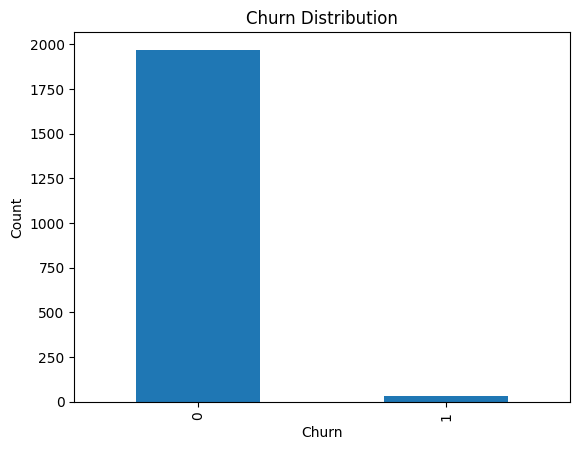

In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import os

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import confusion_matrix, classification_report

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input

# Task 1: Dataset understanding

# Load dataset
df = pd.read_csv("dataset/customer_churn_nn.csv")
print(df.head())

# Number of rows and columns
print("no of rows and columns: ", df.shape)

# Type of input feature
print("Type of input features: \n", df.dtypes)

# Target variable description
churn_counts = df['churn'].value_counts()

print("Customer Retained (0): ", churn_counts[0])
print("Customer Churned (1): ", churn_counts[1])

# Missing value check
print("Missing Value: \n", df.isnull().sum())

# Basic statistical summary
print("Statistical Summary: \n", df.describe())

# Distribution of target variable
df["churn"].value_counts().plot(kind="bar")
plt.title("Churn Distribution")
plt.xlabel('Churn')
plt.ylabel('Count')
plt.show()



In [14]:
# Task 2: Data preprocessing

# Handling missing values
missing_values = df.isnull().sum()
print(missing_values)

if missing_values.sum() == 0:
    print("\nThere are no missing values in the dataset.")
else:
    print("\nMissing values are present in the dataset")

# Drop unnecessary Column
# We should drop customer_id column as it is only an identifier and does not help in prediction.

# Remove customer_id column
df = df.drop("customer_id", axis=1)
print("Customer id dropped")

# Encoding categorical columns
# Categorical columns: `region`, `plan_type`, `contract_type`, `payment_method`

# List of categorical columns
categorical_cols = ['region', 'plan_type', 'contract_type', 'payment_method']

# Apply label encoding
le = LabelEncoder()

for col in categorical_cols:
    df[col] = le.fit_transform(df[col])

# Display dataset after encoding
print(df.head())

# Feature Scaling / normalization
# Features
X = df.drop("churn", axis = 1)

# Target variable
y = df["churn"]

# Apply standard scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
print(X_scaled)

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42
)

# Display shapes
print("X_train shape: ", X_train.shape)
print("X_test shape: ", X_test.shape)
print("y_train shape: ", y_train.shape)
print("y_test shape: ", y_test.shape)

customer_id                     0
region                          0
plan_type                       0
contract_type                   0
payment_method                  0
tenure_months                   0
monthly_charges_inr             0
avg_login_days_per_month        0
support_tickets_last_90_days    0
payment_delay_days              0
data_usage_gb                   0
satisfaction_score              0
last_complaint_days_ago         0
discount_percent                0
autopay_enabled                 0
referral_count                  0
churn                           0
dtype: int64

There are no missing values in the dataset.
Customer id dropped
   region  plan_type  contract_type  payment_method  tenure_months  \
0       3          3              0               1             30   
1       4          2              0               4             15   
2       0          3              0               0             72   
3       4          2              0               0             

In [15]:
# Task 3: Neural Network Model Building

# Create sequential model
model = Sequential()

# Add input layer and activation function in hidden layer
model.add(Input(shape = (X_train.shape[1],)))
model.add(Dense(16, activation='relu'))

# Second hidden layer
model.add(Dense(8, activation='relu'))

# Add output layer
model.add(Dense(1, activation='sigmoid'))

# Compile the model
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()



Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_26 (Dense)                │ (None, 16)             │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_27 (Dense)                │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_28 (Dense)                │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 401 (1.57 KB)

 Trainable params: 401 (1.57 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.2375 - loss: 1.0401 - val_accuracy: 0.5125 - val_loss: 0.7346
Epoch 2/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7391 - loss: 0.5775 - val_accuracy: 0.9156 - val_loss: 0.4400
Epoch 3/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9648 - loss: 0.3607 - val_accuracy: 0.9781 - val_loss: 0.3007
Epoch 4/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9852 - loss: 0.2489 - val_accuracy: 0.9781 - val_loss: 0.2249
Epoch 5/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9867 - loss: 0.1825 - val_accuracy: 0.9781 - val_loss: 0.1790
Epoch 6/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9867 - loss: 0.1415 - val_accuracy: 0.9781 - val_loss: 0.1513
Epoch 7/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9867 - loss: 0.1155 - val_accuracy: 0.9781 - val_loss: 0.1346
Epoch 8/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9867 - loss: 0.0989 - val_accuracy: 0.9781 - val_loss:

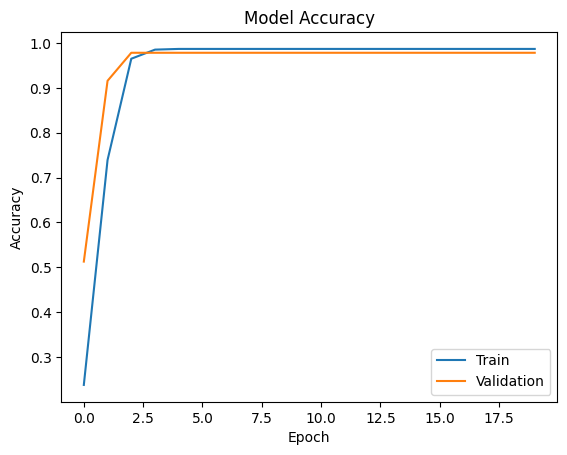

In [16]:
# Task 4: Training and Evaluation
# Train the model

history = model.fit(
    X_train,
    y_train,
    epochs=20,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

# Evaluate on test data
test_loss, test_accuracy = model.evaluate(X_test, y_test)

print("Test loss: ", test_loss)
print("Test Accuracy: ", test_accuracy)

# Training accuracy and loss
print("Training loss: ", history.history['loss'][-1])
print("Training Accuracy: ", history.history['accuracy'][-1])

# Confusion matrix
# Predict probabilities
y_pred = model.predict(X_test)

# Convert probabilities into class labels
y_pred_classes = (y_pred > 0.5).astype(int)

# Confusion matrix
cm = confusion_matrix(y_test, y_pred_classes)
print("Confusion Matrix:\n", cm)

# Classification report
print("Classification Report:\n", classification_report(y_test, y_pred_classes, zero_division=0))

# Plot accuracy and loss graph
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title("Model Accuracy")
plt.ylabel("Accuracy")
plt.xlabel("Epoch")
plt.legend(['Train', 'Validation'])
os.makedirs("results", exist_ok=True)
plt.savefig('results/evaluation_outputs.png')
plt.show()

In [17]:
# Task 5: Hyperparameter Experimentation

# Experiment 1
model1 = Sequential([
    Input(shape=(X_train.shape[1],)),
    Dense(16, activation='relu'),
    Dense(8, activation='relu'),
    Dense(1, activation='sigmoid')
])

model1.compile(optimizer='adam',
               loss='binary_crossentropy',
               metrics=['accuracy'])

history1 = model1.fit(X_train, y_train,
                      epochs=20, 
                      batch_size=32, 
                      verbose=0)

loss1, acc1 = model1.evaluate(X_test, y_test, verbose=0)
print("Experiment 1 Accuracy: ", acc1)

# Experiment 2
model2 = Sequential([
    Input(shape=(X_train.shape[1],)),
    Dense(32, activation='relu'),
    Dense(16, activation='relu'),
    Dense(1, activation='sigmoid')
])

model2.compile(optimizer='adam',
               loss='binary_crossentropy',
               metrics=['accuracy'])

history2 = model2.fit(X_train, y_train,
                      epochs=30, 
                      batch_size=16, 
                      verbose=0)

loss2, acc2 = model2.evaluate(X_test, y_test, verbose=0)
print("Experiment 2 Accuracy: ", acc2)

# Experiment 3
model3 = Sequential([
    Input(shape=(X_train.shape[1],)),
    Dense(64, activation='relu'),
    Dense(32, activation='relu'),
    Dense(16, activation='relu'),
    Dense(1, activation='sigmoid')
])

model3.compile(optimizer='adam',
               loss='binary_crossentropy',
               metrics=['accuracy'])

history3 = model3.fit(X_train, y_train,
                      epochs=40, 
                      batch_size=32, 
                      verbose=0)

loss3, acc3 = model3.evaluate(X_test, y_test, verbose=0)
print("Experiment 3 Accuracy: ", acc3)

# Create comparison table
comparison_df = pd.DataFrame({
    'Experiment': ['Experiment 1', 'Experiment 2', 'Experiment 3'],
    'Accuracy': [acc1, acc2, acc3]
})

# Save CSV
comparison_df.to_csv('results/model_comparison_table.csv', index=False)
print("Model comparison table saved successfully")

Experiment 1 Accuracy:  0.9825000166893005
Experiment 2 Accuracy:  0.9775000214576721
Experiment 3 Accuracy:  0.9700000286102295
Model comparison table saved successfully


# Task 6: Final Reflection 

## 1. Role of Weights and Biases

Weights help the neural network learn relationships between input features and output values. Biases allow the model to shift activation functions and improve flexibility during learning.

---

## 2. Why Activation Functions are Required

Activation functions introduce non-linearity into the neural network. Without activation functions, the model behaves like a simple linear model and cannot learn complex patterns.

---

## 3. What Happens When Learning Rate is Too High or Too Low?

### High Learning Rate
- The model may overshoot the optimal values.
- Training becomes unstable.
- Loss may fluctuate significantly.

### Low Learning Rate
- Training becomes very slow.
- The model may take a long time to converge.

---

## 4. Underfitting vs Overfitting

### Underfitting
Underfitting occurs when the model cannot learn enough patterns from the training data.

### Overfitting
Overfitting occurs when the model memorizes the training data and performs poorly on unseen data.

### Observation for This Model
- The model performed well on both training and validation datasets.
- Slight overfitting may occur in deeper models with many epochs.
- Proper hyperparameter tuning helps improve generalization performance.
